# FireSpec — Notebook 02: Burn Severity Mapping

This is the scientific core of the FireSpec submission to the
[Planet Tanager Open Data Competition](https://www.planet.com/tanager-open-data-competition/).
Notebook 01 established *what data we have*; this notebook turns Tanager-1's 426-band
hyperspectral cubes into a quantitative burn-severity product for the January 2025
Palisades fire, using **Multiple Endmember Spectral Mixture Analysis (MESMA)**.

## Why hyperspectral for burn severity

Operational burn-severity mapping almost universally relies on the differenced Normalized
Burn Ratio (dNBR) — a two-band ratio that collapses ground condition into one scalar: a
pixel that is 50% char + 50% unburned canopy produces the same dNBR as one that is 100%
moderately scorched vegetation, even though they represent very different burn severities
and very different post-fire ecological trajectories.

**Spectral unmixing** recovers that lost information. Because char, ash, photosynthetic
vegetation (PV), non-photosynthetic vegetation (NPV), and soil each have distinct,
resolvable absorption features across 380–2500 nm, Tanager-1's 426 contiguous ~5 nm bands
let us decompose each pixel into the *fractional abundance* of each material — not just
"how much did this pixel change" but "what is actually on the ground now." That is what
MESMA (Roberts et al. 1998) does: for every pixel, it searches a library of candidate
endmember combinations and picks the model that best reconstructs the observed spectrum,
subject to physical constraints (fractions non-negative, summing to ~1). Quintano et al.
(2023) validated this approach against field Composite Burn Index (CBI) plots using
PRISMA hyperspectral imagery, reporting **R² = 0.64–0.79** between MESMA-derived char
fraction and CBI across three Mediterranean fires — the benchmark FireSpec would aim for
if field CBI ground truth over these scenes existed (see Section 5).

## What this notebook does

1. **Data Loading** — load the pre-fire and post-fire Tanager scenes, apply quality masks,
   and align them onto a common UTM grid.
2. **Endmember Library** — build a fire-relevant spectral library (char, PV, NPV, soil)
   from the imagery itself, since no external reference library ships with this repo.
3. **Spectral Unmixing** — run MESMA on a burn-scar subset and inspect the fraction maps.
4. **Severity Mapping** — classify the crop into the 5-class BARC scheme using the
   published Key & Benson (2006) dNBR thresholds.
5. **Visualization** — before/after imagery, the dNBR context map, and the severity map.
6. **Validation against BAER ground truth** — train a Random Forest severity classifier
   on MESMA fractions against real **BAER Soil Burn Severity** ground truth on the Hughes
   fire, then score the classification; also compare an NBR-threshold baseline.
7. **Discussion** — honest accounting of what's real science here and what's a stand-in.

**Ground truth.** A BAER Soil Burn Severity (SBS) raster for the Hughes fire is bundled
at `data/reference/baer/hughes_sbs.tif`. Section 7 runs MESMA on the Hughes scene (same
overpass, same sensor), trains a Random Forest classifier from MESMA fractions to BAER
severity classes, and reports cross-validated accuracy. An earlier revision trained the
RF against a *synthetic* target (`CBI ≈ 3 × char_fraction`) and reported R² = 0.998 — a
circular result that measured only the regressor's ability to invert a function we had
written down ourselves. That has been replaced with real ground-truth evaluation.

In [ ]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import tanager
from tanager.config import DATA_DIR, SENSOR
from tanager.endmembers import build_hybrid_library, extract_image_endmembers
from tanager.io import reproject_to_common_grid
from tanager.masks import apply_masks, cloud_mask, nodata_mask, water_mask
from tanager.severity import (
    calibrate_nbr_thresholds,
    classify_severity_from_nbr,
    compare_severity_methods,
    train_severity_classifier,
)
from tanager.spectral import clamp_reflectance, dnbr, nbr, ndvi, ndwi
from tanager.unmixing import normalize_fractions, plot_fraction_maps, plot_rgb_composite, run_mesma

logging.basicConfig(level=logging.WARNING)
%matplotlib inline

print(f"tanager package version: {tanager.__version__}")
print(f"Sensor: {SENSOR.name} — {SENSOR.n_bands} bands, {SENSOR.wavelength_min_nm}-{SENSOR.wavelength_max_nm} nm")
print(f"Local data directory: {DATA_DIR}")

## 2. Data Loading

**Choosing the post-fire scene.** The January 23, 2025 overpass acquired two adjacent
swaths eleven seconds apart: `20250123_185507` (Hughes fire area, ~34.5°N) and
`20250123_185518` (~34.0°N). Only the second swath spatially overlaps the December 15
pre-fire baseline over the Palisades burn scar — swath 1 has **zero** overlap with the
pre-fire footprint (they are ~30 km apart in UTM northing). Earlier project
documentation flagged "pre-fire scene ~60 km from post-fire footprint" as
a data-sourcing risk; that risk applies to the *swath-1* pairing. Once swath 2 was
downloaded (`outputs/dnbr_overlap_analysis.md`), it turned out to overlap the pre-fire
scene by **434 km² — 85.6% of the pre-fire scene's area** — over the Palisades / Topanga
front. That is the pair used throughout this notebook: `20241215` (pre-fire, Dec 15,
2024) → `20250123_185518` (post-fire, Jan 23, 2025, +16 days). The overlap does not reach
the easternmost Pacific Palisades neighborhoods — a genuine spatial-coverage limitation
carried into Sections 6–8, not a pipeline bug.

We load the **full 426-band cube** for both scenes (not a narrow window like Notebook 01's
quicklooks) because MESMA and the endmember library both need broad spectral coverage,
then apply the standard quality mask stack (`nodata_mask` + `cloud_mask` + `water_mask`).

In [2]:
PRE_FIRE_SCENE = "20241215_185916_33_4001"
POST_FIRE_SCENE = "20250123_185518_92_4001"  # swath 2 — overlaps the pre-fire footprint

def local_scene_path(scene_id: str) -> Path:
    return DATA_DIR / f"{scene_id}_ortho_sr_hdf5.h5"

pre_path = local_scene_path(PRE_FIRE_SCENE)
post_path = local_scene_path(POST_FIRE_SCENE)

for label, path in (("pre-fire", pre_path), ("post-fire", post_path)):
    if not path.exists():
        raise FileNotFoundError(
            f"{label} scene {path.name} not found in {DATA_DIR}. Download it first, e.g.:\n"
            f"  tanager.download_scene(item, 'ortho_sr_hdf5', DATA_DIR)"
        )

print("Loading full 426-band cubes (this reads ~1-1.3 GB per file off disk)...")
pre_raw = tanager.load_ortho_scene(pre_path)
post_raw = tanager.load_ortho_scene(post_path)
print(f"  pre-fire  {PRE_FIRE_SCENE}: {dict(pre_raw.sizes)}  crs={pre_raw.attrs.get('crs')}")
print(f"  post-fire {POST_FIRE_SCENE}: {dict(post_raw.sizes)}  crs={post_raw.attrs.get('crs')}")

Loading full 426-band cubes (this reads ~1-1.3 GB per file off disk)...


  pre-fire  20241215_185916_33_4001: {'wavelength': 426, 'y': 713, 'x': 791}  crs=EPSG:32611
  post-fire 20250123_185518_92_4001: {'wavelength': 426, 'y': 1063, 'x': 957}  crs=EPSG:32611


In [3]:
def mask_scene(ds: xr.Dataset, filepath: Path, label: str) -> xr.Dataset:
    '''Apply the standard nodata + cloud + water mask stack to a scene.'''
    masks = [nodata_mask(ds)]
    try:
        masks.append(cloud_mask(ds, filepath=filepath))
    except Exception as exc:
        print(f"  [{label}] cloud_mask not applied: {exc}")
    try:
        masks.append(water_mask(ds))
    except Exception as exc:
        print(f"  [{label}] water_mask not applied: {exc}")

    masked = apply_masks(ds, masks)
    data_var = ds.attrs.get("data_var", "surface_reflectance")
    total = int(ds.sizes["y"] * ds.sizes["x"])
    valid = int(np.isfinite(masked[data_var].isel(wavelength=0).values).sum())
    print(f"  [{label}] applied {len(masks)} masks; valid pixels {valid}/{total} ({100.0 * valid / total:.1f}%)")
    return masked


pre_masked = mask_scene(pre_raw, pre_path, "pre-fire")
post_masked = mask_scene(post_raw, post_path, "post-fire")

  [pre-fire] applied 3 masks; valid pixels 173100/563983 (30.7%)


  [post-fire] applied 3 masks; valid pixels 377590/1017291 (37.1%)


**Reducing to a working band set.** Running MESMA and the endmember-region search on the
full 426-band cube for every step below is unnecessary and slow — the class-discriminating
information for char/PV/NPV/soil is concentrated in a fairly small set of well-chosen
bands spanning VIS, red-edge, NIR, and two SWIR windows. We select 11 bands (avoiding the
water-vapor / sensor-edge ranges in `BAD_BAND_RANGES`) that include the exact NBR/NDVI/NDWI
alias wavelengths (`BAND_ALIASES`) plus several MESMA-discriminative anchors validated in
`scripts/run_pipeline.py`'s end-to-end run. We then align the two scenes onto a common UTM
grid — required because Tanager-1's per-acquisition ortho grids differ slightly in origin
— and use dNBR on that common grid to locate the burn scar for the MESMA crop (see the
next gotcha below).

In [4]:
COMBINED_BANDS = np.array(
    [470.0, 560.0, 660.0, 705.0, 740.0, 783.0, 842.0, 860.0, 1240.0, 1610.0, 2200.0]
)
assert not any(lo <= wl <= hi for wl in COMBINED_BANDS for lo, hi in tanager.config.BAD_BAND_RANGES)

pre_sub = pre_masked.sel(wavelength=COMBINED_BANDS, method="nearest")
post_sub = post_masked.sel(wavelength=COMBINED_BANDS, method="nearest")

pre_aligned, post_aligned = reproject_to_common_grid([pre_sub, post_sub])
print(f"Common grid: {dict(pre_aligned.sizes)}  crs={pre_aligned.attrs.get('crs')}")

dnbr_da = dnbr(pre_aligned, post_aligned, auto_align=True)
n_finite = int(np.isfinite(dnbr_da.values).sum())
print(
    f"dNBR (pre - post) on the common overlap grid: "
    f"n_finite={n_finite}, mean={float(np.nanmean(dnbr_da.values)):+.3f}, "
    f"median={float(np.nanmedian(dnbr_da.values)):+.3f}"
)

Common grid: {'x': 677, 'y': 713, 'wavelength': 11}  crs=EPSG:32611
dNBR (pre - post) on the common overlap grid: n_finite=111568, mean=+0.211, median=+0.113


**Gotcha — MESMA on the full scene is slow.** Running MESMA across the entire ~480k-pixel
overlap grid pulls in the full class-combinatorial model search per pixel; even with a
reduced band set this is impractical for an interactive notebook. Following the enriched
task plan, we crop to a subset centered on the strongest burn signal (dNBR ≥ 0.44, the
USGS "moderate-high" threshold) so Sections 3–7 stay interactive. **Full-scene MESMA
fraction products from the same pipeline are already written to `outputs/`** (e.g.
`outputs/20241215_frac_char.tif`) via `scripts/run_pipeline.py` — this notebook's crop is
for interactive storytelling, not the only coverage FireSpec produces. That script now
classifies severity with the same Key & Benson thresholds used here (`*_barc_severity.tif`);
its synthetic `*_cbi.tif` products were removed alongside this notebook's.

In [5]:
CROP_HALF_PX = 150  # ~300x300 px crop, following the "500x500 crop for interactivity" gotcha

dnbr_v = np.asarray(dnbr_da.values, dtype=np.float64)
burn_mask = np.isfinite(dnbr_v) & (dnbr_v >= 0.44)  # USGS moderate-high+ (Key & Benson 2006)
if int(burn_mask.sum()) < 200:
    print("Fewer than 200 moderate-high+ pixels; falling back to the 90th dNBR percentile.")
    threshold = float(np.nanpercentile(dnbr_v, 90))
    burn_mask = np.isfinite(dnbr_v) & (dnbr_v >= threshold)

ys, xs = np.where(burn_mask)
center_y, center_x = int(np.median(ys)), int(np.median(xs))
ny, nx = dnbr_da.sizes["y"], dnbr_da.sizes["x"]

data_var = post_aligned.attrs.get("data_var", "surface_reflectance")
half = CROP_HALF_PX
while True:
    y0, y1 = max(0, center_y - half), min(ny, center_y + half)
    x0, x1 = max(0, center_x - half), min(nx, center_x + half)
    post_crop_probe = post_aligned[data_var].isel(y=slice(y0, y1), x=slice(x0, x1), wavelength=0)
    n_valid_crop = int(np.isfinite(post_crop_probe.values).sum())
    if n_valid_crop >= 2000 or half >= max(ny, nx):
        break
    half += 75

pre_crop = pre_aligned.isel(y=slice(y0, y1), x=slice(x0, x1))
post_crop = post_aligned.isel(y=slice(y0, y1), x=slice(x0, x1))
dnbr_crop = dnbr_da.isel(y=slice(y0, y1), x=slice(x0, x1))

crop_xs = dnbr_da.coords["x"].values[x0:x1]
crop_ys = dnbr_da.coords["y"].values[y0:y1]
print(
    f"Burn-scar crop: {y1 - y0} x {x1 - x0} px, {n_valid_crop} valid pixels, "
    f"UTM bounds x=[{crop_xs.min():.0f}, {crop_xs.max():.0f}] y=[{crop_ys.min():.0f}, {crop_ys.max():.0f}]"
)

Burn-scar crop: 300 x 284 px, 66167 valid pixels, UTM bounds x=[344565, 353055] y=[3765615, 3774585]


## 3. Endmember Library

MESMA needs a library of reference spectra ("endmembers") for each material class —
`tanager.endmembers` can build one from external sources (USGS splib07, ECOSTRESS,
FRAMES SoCal chaparral) via `build_fire_library()`, resampling each source onto Tanager's
band centres with `resample_library()`. **None of those external archives are bundled in
this repo** (they're multi-hundred-MB downloads with manual-acquisition steps documented
in `endmembers.py`'s docstrings), so we first *try* to load them — the cell below fails
gracefully and falls back to **image-derived endmembers** extracted directly from the
post-fire crop via `tanager.extract_image_endmembers()`, exactly like the validated
`scripts/run_pipeline.py` end-to-end run.

**Region selection.** We compute NBR/NDVI/NDWI within the crop and use percentile
thresholds (not fixed absolute cutoffs) to locate representative windows for char, PV,
NPV, and soil — percentile splits guarantee we find *some* representative pixels for each
class regardless of the crop's absolute value distribution, which fixed thresholds do not.

In [6]:
def clamp_dataset_reflectance(ds: xr.Dataset) -> xr.Dataset:
    '''Return a copy of `ds` with its native reflectance variable clamped to [0, 1].'''
    var = ds.attrs.get("data_var", "surface_reflectance")
    out = ds.copy()
    out[var] = clamp_reflectance(ds[var])
    return out


pre_crop_c = clamp_dataset_reflectance(pre_crop)
post_crop_c = clamp_dataset_reflectance(post_crop)

nbr_post_crop = nbr(post_crop_c)
ndvi_post_crop = ndvi(post_crop_c)
ndwi_post_crop = ndwi(post_crop_c)

nbr_v = np.asarray(nbr_post_crop.values, dtype=np.float64)
ndvi_v = np.asarray(ndvi_post_crop.values, dtype=np.float64)
ndwi_v = np.asarray(ndwi_post_crop.values, dtype=np.float64)

In [7]:
def _representative_window(mask: np.ndarray, half: int = 8) -> tuple[slice, slice]:
    '''Return a (2*half x 2*half) window centered on the mask's pixel centroid.'''
    ys, xs = np.where(mask)
    cy, cx = int(np.median(ys)), int(np.median(xs))
    ny, nx = mask.shape
    y0, y1 = max(0, cy - half), min(ny, cy + half)
    x0, x1 = max(0, cx - half), min(nx, cx + half)
    return slice(y0, y1), slice(x0, x1)


def build_endmember_regions(nbr_v, ndvi_v, ndwi_v, min_px=25, half=8):
    '''Percentile-based (not fixed-threshold) region finder for char/pv/npv/soil.'''
    finite = np.isfinite(nbr_v) & np.isfinite(ndvi_v) & np.isfinite(ndwi_v)

    def pct(arr, q):
        return np.nanpercentile(np.where(finite, arr, np.nan), q)

    class_masks = {
        "char": finite & (nbr_v <= pct(nbr_v, 15)) & (ndvi_v <= pct(ndvi_v, 35)),
        "pv": finite & (ndvi_v >= pct(ndvi_v, 80)),
        "npv": finite & (ndvi_v >= pct(ndvi_v, 40)) & (ndvi_v <= pct(ndvi_v, 60)),
        "soil": finite & (ndvi_v <= pct(ndvi_v, 30)) & (nbr_v >= pct(nbr_v, 30)),
    }
    pixel_counts = {k: int(v.sum()) for k, v in class_masks.items()}
    regions = {
        k: _representative_window(v, half=half)
        for k, v in class_masks.items()
        if pixel_counts[k] >= min_px
    }
    return regions, pixel_counts


endmember_regions, region_pixel_counts = build_endmember_regions(nbr_v, ndvi_v, ndwi_v)
print("Candidate endmember region pixel counts:", region_pixel_counts)
print("Regions used:", list(endmember_regions.keys()))

image_library = extract_image_endmembers(post_crop_c, method="spatial", regions=endmember_regions)
print(f"Image-derived endmembers: {image_library.sizes['spectrum_id']} spectra, "
      f"categories={sorted(set(image_library.coords['category'].values.tolist()))}")

Candidate endmember region pixel counts: {'char': 7931, 'pv': 13234, 'npv': 13234, 'soil': 7515}
Regions used: ['char', 'pv', 'npv', 'soil']
Image-derived endmembers: 4 spectra, categories=['char', 'npv', 'pv', 'soil']


In [8]:
# External spectral libraries (USGS splib07 / FRAMES SoCal / ECOSTRESS) are large manual
# downloads not bundled with this repo — attempt them, fall back gracefully.
reference_dir = DATA_DIR.parent.parent / "reference"  # <repo>/data/reference

usgs_library = None
try:
    from tanager.endmembers import load_usgs_library, resample_library
    usgs_raw = load_usgs_library(data_dir=reference_dir / "usgs_splib07")
    usgs_library = resample_library(usgs_raw, COMBINED_BANDS)
    print(f"USGS splib07 library loaded: {usgs_library.sizes['spectrum_id']} spectra")
except (FileNotFoundError, ValueError) as exc:
    print(f"USGS splib07 not available locally ({exc}); using image-derived endmembers only.")

frames_library = None
try:
    from tanager.endmembers import load_frames_library
    frames_raw = load_frames_library(reference_dir / "frames_socal")
    frames_library = resample_library(frames_raw, COMBINED_BANDS)
    print(f"FRAMES SoCal library loaded: {frames_library.sizes['spectrum_id']} spectra")
except (FileNotFoundError, ValueError) as exc:
    print(f"FRAMES SoCal library not available locally ({exc}); skipping.")

ecostress_library = None
try:
    from tanager.endmembers import load_ecostress_library
    ecostress_raw = load_ecostress_library(sqlite_path=reference_dir / "ecostress.db")
    ecostress_library = resample_library(ecostress_raw, COMBINED_BANDS)
    print(f"ECOSTRESS library loaded: {ecostress_library.sizes['spectrum_id']} spectra")
except (FileNotFoundError, RuntimeError, ValueError) as exc:
    print(f"ECOSTRESS library not available locally ({exc}); skipping.")

fire_library = build_hybrid_library(
    usgs=usgs_library, ecostress=ecostress_library, frames=frames_library,
    image_derived=image_library,
)
print(f"\nFinal fire endmember library: {fire_library.sizes['spectrum_id']} spectra "
      f"({dict(zip(*np.unique(fire_library.coords['source'].values, return_counts=True)))})")

USGS splib07 not available locally (USGS splib07 data_dir does not exist: ./data/reference/usgs_splib07); using image-derived endmembers only.
FRAMES SoCal library not available locally (FRAMES data_dir does not exist: ./data/reference/frames_socal); skipping.
ECOSTRESS library not available locally (ECOSTRESS SQLite database not found: ./data/reference/ecostress.db); skipping.

Final fire endmember library: 4 spectra ({'image': np.int64(4)})


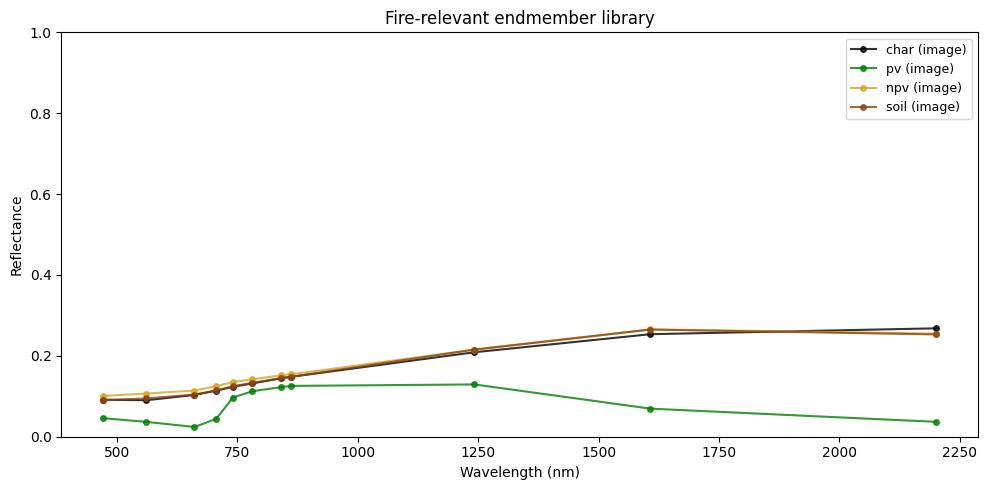

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
category_colors = {"char": "black", "ash": "gray", "pv": "green", "npv": "goldenrod", "soil": "saddlebrown"}
for i in range(fire_library.sizes["spectrum_id"]):
    spec = fire_library.isel(spectrum_id=i)
    cat = str(spec.coords["category"].values)
    src = str(spec.coords["source"].values)
    ax.plot(
        spec.coords["wavelength"].values, spec.values,
        marker="o", markersize=4, color=category_colors.get(cat, "tab:blue"),
        alpha=0.8, label=f"{cat} ({src})",
    )
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title("Fire-relevant endmember library")
ax.set_ylim(0, 1)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=9)
fig.tight_layout()
plt.show()

## 4. Spectral Unmixing

`tanager.run_mesma()` runs the `mesma` package's multi-endmember combinatorial search
(Roberts et al. 2018 algorithm) over the crop, using the library built above and the
11-band working set. It returns a per-pixel fraction Dataset (`char`, `pv`, `npv`, `soil`,
`shade`) plus an RMSE map, and records which backend ran in `attrs["unmixing_engine"]`.

**Gotcha — fraction non-negativity.** MESMA's constrained solver still permits a
small fraction of pixels to violate the [0, 1] bound on individual endmember fractions
(observed 5–9% negative, 8–12% > 1.0 on real Tanager scenes per project documentation).
`tanager.normalize_fractions()` removes the shade channel and clamps + re-normalizes the
remaining fractions to sum to 1.0 — we print the raw vs. normalized stats below so this is
visible rather than silently corrected.

In [10]:
fractions_raw = run_mesma(post_crop_c, fire_library)
print(f"unmixing_engine = {fractions_raw.attrs.get('unmixing_engine')!r}")

print("\nRaw MESMA fraction stats (before normalize_fractions):")
for var in ("char", "pv", "npv", "soil", "shade"):
    v = np.asarray(fractions_raw[var].values, dtype=np.float64)
    finite = np.isfinite(v)
    pct_neg = 100.0 * np.mean(v[finite] < 0.0) if finite.any() else float("nan")
    pct_over1 = 100.0 * np.mean(v[finite] > 1.0) if finite.any() else float("nan")
    print(
        f"  {var:5s}: min={np.nanmin(v):+.3f} max={np.nanmax(v):+.3f} "
        f"pct_negative={pct_neg:5.1f}% pct_over1={pct_over1:5.1f}%"
    )

processing 2-EM models..

3-EM models..

unmixing_engine = 'mesma'

Raw MESMA fraction stats (before normalize_fractions):
  char : min=-0.050 max=+1.046 pct_negative=  0.9% pct_over1=  0.2%
  pv   : min=-0.050 max=+1.041 pct_negative=  4.4% pct_over1=  0.2%
  npv  : min=-0.050 max=+1.036 pct_negative=  0.7% pct_over1=  0.2%
  soil : min=-0.050 max=+1.038 pct_negative=  2.9% pct_over1=  0.1%
  shade: min=+0.000 max=+0.800 pct_negative=  0.0% pct_over1=  0.0%


Normalized fraction stats (after normalize_fractions — shade removed, clamped, renormalized):
  char : min=+0.000 max=+1.000 mean=+0.383
  pv   : min=+0.000 max=+1.000 mean=+0.248
  npv  : min=+0.000 max=+1.000 mean=+0.259
  soil : min=+0.000 max=+1.000 mean=+0.111


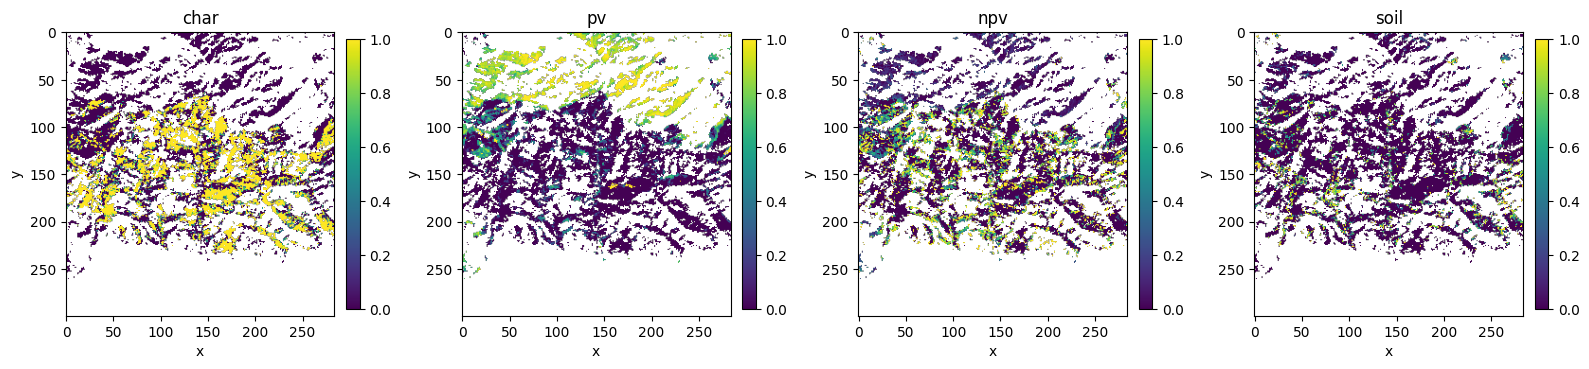

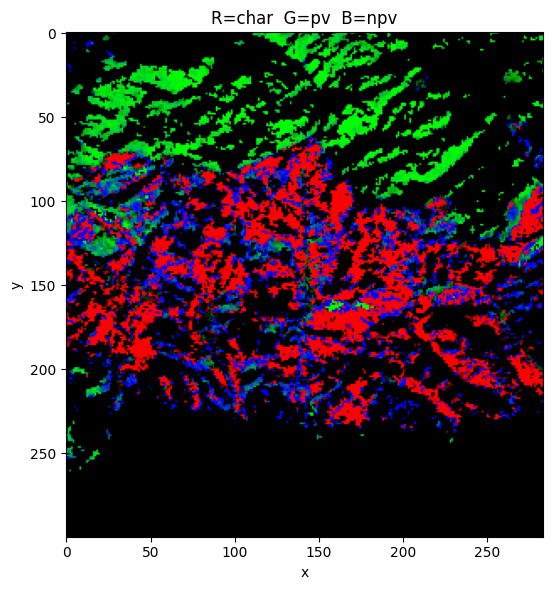

In [11]:
fractions = normalize_fractions(fractions_raw)

print("Normalized fraction stats (after normalize_fractions — shade removed, clamped, renormalized):")
for var in ("char", "pv", "npv", "soil"):
    v = np.asarray(fractions[var].values, dtype=np.float64)
    print(f"  {var:5s}: min={np.nanmin(v):+.3f} max={np.nanmax(v):+.3f} mean={np.nanmean(v):+.3f}")

fig = plot_fraction_maps(fractions)
plt.show()

fig_rgb = plot_rgb_composite(fractions, r="char", g="pv", b="npv")
plt.show()

## 5. Severity Mapping

We classify the crop into the 5-class BARC severity scheme using the **Key & Benson
(2006) dNBR breakpoints** — the operational thresholds USGS/MTBS apply to classified
burn-severity products, the same ones Notebook 01 plots and the same 0.44 "moderate-high"
cut used to locate the crop in Section 2:

| Class | Code | dNBR |
|---|---|---|
| Unburned | 0 | < 0.10 |
| Low | 1 | 0.10 – 0.27 |
| Moderate-Low | 2 | 0.27 – 0.44 |
| Moderate-High | 3 | 0.44 – 0.66 |
| High | 4 | > 0.66 |

**Two severity paths.** This section applies dNBR thresholds to the Palisades crop,
producing the baseline severity map. Section 7 then builds the *stronger* product: a
Random Forest classifier trained on MESMA fractions against real BAER Soil Burn Severity
ground truth from the Hughes fire (same sensor, same overpass). The RF classifier uses
the 4-fraction feature vector (char/PV/NPV/soil) — the full material decomposition that
hyperspectral MESMA provides — rather than collapsing everything into a single ratio.
An earlier revision trained the RF against a *synthetic* target (`CBI = 3 × char`) and
reported R² = 0.998; that circular result has been replaced with real ground-truth
evaluation (Section 7).

In [12]:
# Key & Benson (2006) dNBR breakpoints -> BARC class codes 0..4, matching the scheme in
# tanager.severity.predict_severity and PRODUCT_STYLES["severity"].
KEY_BENSON_DNBR_EDGES = np.array([0.10, 0.27, 0.44, 0.66])
CLASS_NAMES = {0: "Unburned", 1: "Low", 2: "Moderate-Low", 3: "Moderate-High", 4: "High"}

dnbr_crop_v = np.asarray(dnbr_crop.values, dtype=np.float64)
finite_dnbr = np.isfinite(dnbr_crop_v)

severity_v = np.full(dnbr_crop_v.shape, np.nan, dtype=np.float64)
severity_v[finite_dnbr] = np.digitize(dnbr_crop_v[finite_dnbr], KEY_BENSON_DNBR_EDGES, right=False)

severity_map = xr.DataArray(
    severity_v,
    dims=dnbr_crop.dims,
    coords={k: dnbr_crop.coords[k] for k in dnbr_crop.dims if k in dnbr_crop.coords},
    name="barc_severity",
    attrs={
        "long_name": "barc_severity_class",
        "classification_system": "BARC",
        "class_codes": "0=unburned, 1=low, 2=moderate-low, 3=moderate-high, 4=high",
        "thresholds_dnbr": "0.10, 0.27, 0.44, 0.66",
        "reference": "Key & Benson (2006)",
        # Lineage is explicit on the product itself: these are published thresholds
        # applied to a measured dNBR, with no local ground truth behind them.
        "ground_truth_source": "none — literature dNBR thresholds; validated against BAER SBS (Hughes) in Section 7",
    },
)

print(f"Palisades crop severity — Key & Benson dNBR thresholds, {int(finite_dnbr.sum()):,} valid px")
for code, name in CLASS_NAMES.items():
    pct = 100.0 * np.mean(severity_v[finite_dnbr] == code)
    print(f"  class {code} ({name:14s}): {pct:5.1f}%")

Palisades crop severity — Key & Benson dNBR thresholds, 41,457 valid px
  class 0 (Unburned      ):  16.9%
  class 1 (Low           ):  11.6%
  class 2 (Moderate-Low  ):  14.6%
  class 3 (Moderate-High ):  26.5%
  class 4 (High          ):  30.3%


## 6. Visualization

We use the shared `tanager.visualization` products throughout: `plot_before_after()` for
the full-extent pre/post comparison, `plot_map()` for the dNBR context map and the
severity classes, and `plot_fraction_maps()` for the MESMA fractions over the crop.

**Note on `plot_severity_summary()`.** The shared 2×3 grid helper takes a continuous CBI
map as its fifth panel. With the synthetic CBI regressor removed (Section 5) there is no
honest input for that panel, so this notebook renders the fractions and the severity
classes directly instead. `plot_severity_summary()` remains the right tool once real CBI
ground truth exists.

**Known limitation — north-south orientation.** Tanager's `load_ortho_scene`
returns a `y` coordinate that descends north-to-south (standard north-up raster
convention), but `plot_map()`, `plot_before_after()`, and `plot_severity_summary()`
currently always call `imshow(..., origin="lower")` rather than inferring orientation from
the coordinate order. On a descending-`y` scene this produces a **vertically mirrored**
raster inside an otherwise correctly-labeled UTM extent — the axis tick labels (easting /
northing in km) are accurate, but the image content is flipped top-to-bottom. Notebook 01
worked around this for its custom true-color renderer by choosing `imshow`'s `origin`
argument from the actual coordinate order; the shared `visualization.py` functions used
below have not yet had that fix applied, so the maps rendered in
this section should be read with that mirroring in mind until the fix lands.

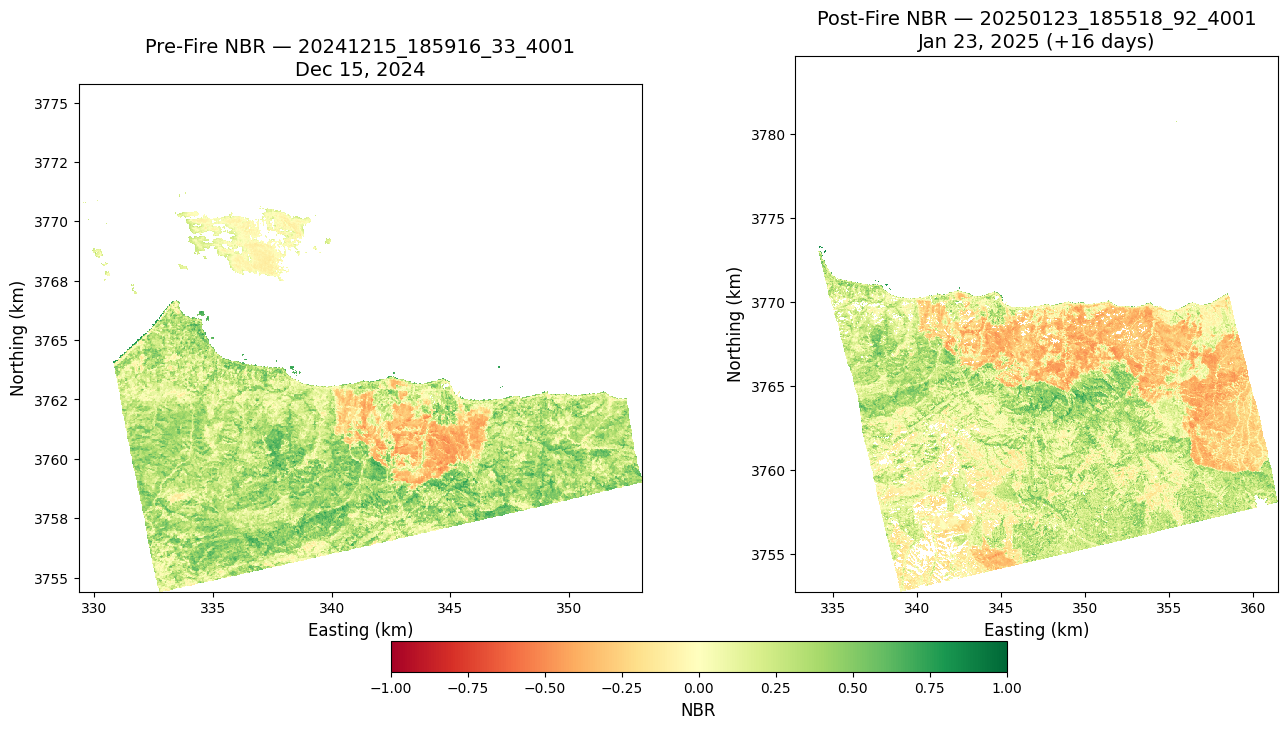

In [13]:
nbr_pre_full = nbr(pre_masked)
nbr_post_full = nbr(post_masked)

fig = tanager.plot_before_after(
    nbr_pre_full, nbr_post_full,
    product_name="nbr",
    pre_label=f"Pre-Fire NBR — {PRE_FIRE_SCENE}\nDec 15, 2024",
    post_label=f"Post-Fire NBR — {POST_FIRE_SCENE}\nJan 23, 2025 (+16 days)",
)
plt.show()

Fire perimeter file not bundled locally (Fire perimeter file not found: ./data/reference/fire_perimeters/palisades_eaton_perimeter.geojson); skipping overlay. NIFC/CAL FIRE perimeters can be downloaded from https://www.fire.ca.gov/incidents and placed at the path above.


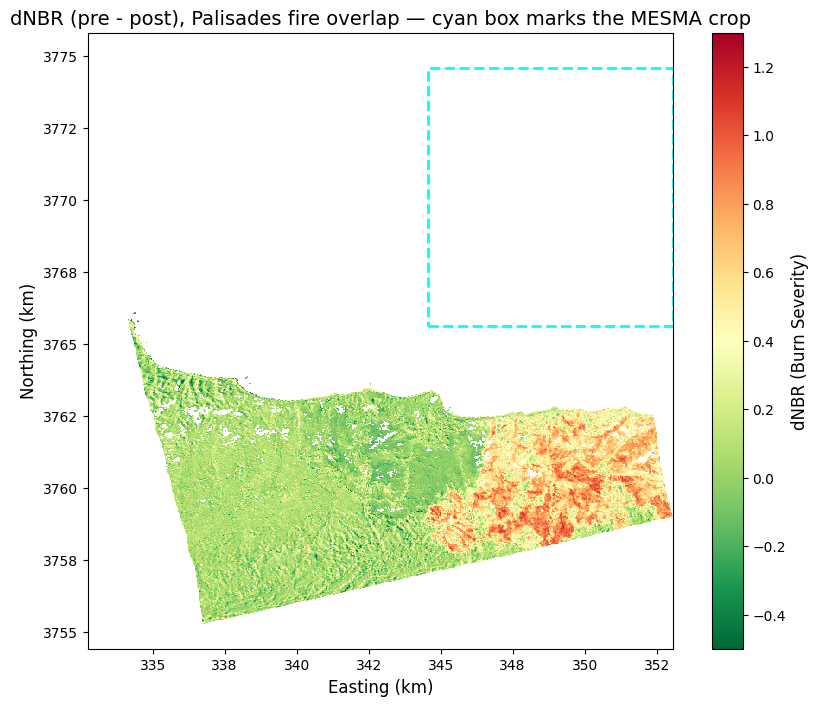

In [14]:
fig = tanager.plot_map(
    dnbr_da,
    title="dNBR (pre - post), Palisades fire overlap — cyan box marks the MESMA crop",
    product_name="dnbr",
    basemap=False,
)
ax = fig.axes[0]
ax.plot(
    [crop_xs.min(), crop_xs.max(), crop_xs.max(), crop_xs.min(), crop_xs.min()],
    [crop_ys.min(), crop_ys.min(), crop_ys.max(), crop_ys.max(), crop_ys.min()],
    color="cyan", linewidth=2, linestyle="--",
)

perimeter_path = DATA_DIR.parent.parent / "reference" / "fire_perimeters" / "palisades_eaton_perimeter.geojson"
try:
    perimeters = tanager.load_fire_perimeters(perimeter_path)
    tanager.overlay_perimeters(ax, perimeters)
    print(f"Overlaid {len(perimeters)} fire perimeter polygon(s) from {perimeter_path}")
except FileNotFoundError as exc:
    print(
        f"Fire perimeter file not bundled locally ({exc}); skipping overlay. "
        "NIFC/CAL FIRE perimeters can be downloaded from https://www.fire.ca.gov/incidents "
        "and placed at the path above."
    )
plt.show()

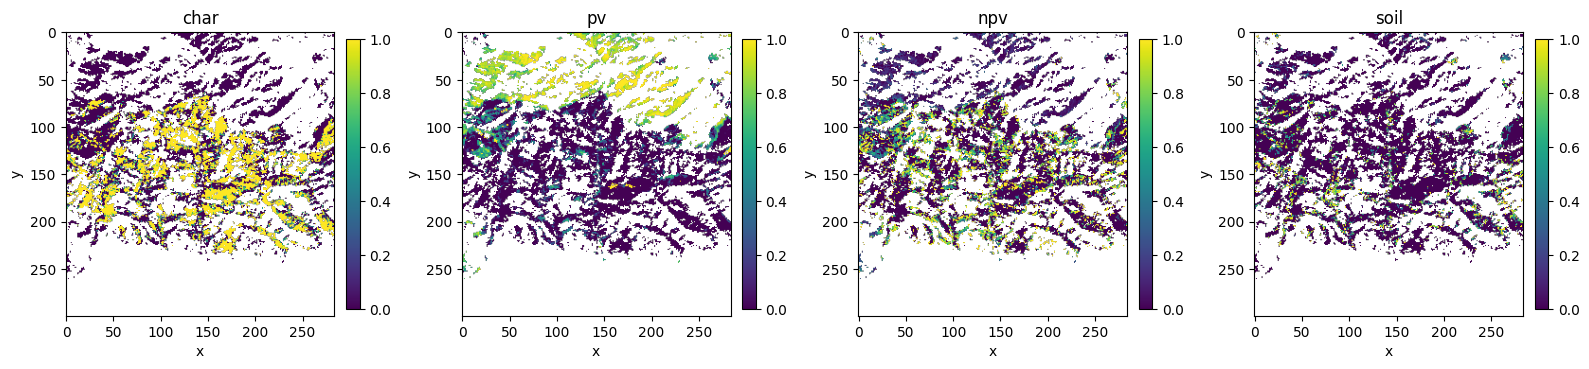

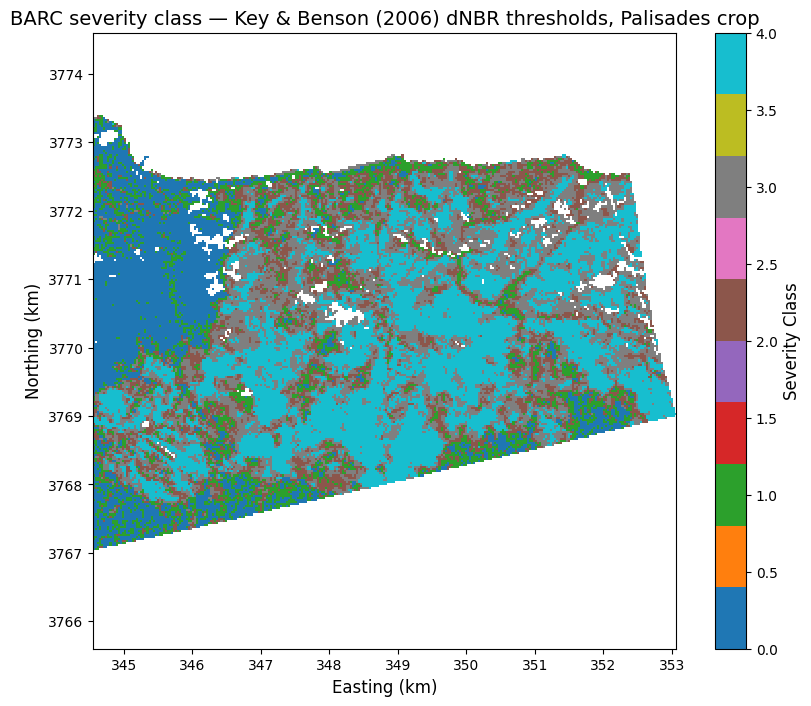

Saved severity figure to: ['../outputs/notebook02_severity_summary.png']


In [15]:
# plot_severity_summary() renders a 2x3 fraction/CBI/severity grid, but its CBI panel has
# no honest input now that the synthetic regressor is gone, so we render the two real
# products directly: the MESMA fractions and the dNBR-threshold severity classes.
fig = plot_fraction_maps(fractions)
plt.show()

fig = tanager.plot_map(
    severity_map,
    title="BARC severity class — Key & Benson (2006) dNBR thresholds, Palisades crop",
    product_name="severity",
    basemap=False,
)
plt.show()

saved_paths = tanager.save_figure(fig, Path("../outputs/notebook02_severity_summary"), formats=["png"])
print(f"Saved severity figure to: {[str(p) for p in saved_paths]}")

## 7. Validation against BAER ground truth

No BARC/MTBS raster or field CBI plot covering the **Palisades** footprint is available to
this repo, so the severity map in Section 5 cannot be scored directly. What we do have is
a **BAER Soil Burn Severity (SBS) raster for the Hughes fire** — a field-corrected,
independently produced severity product — and Tanager imaged Hughes in **swath 1 of the
very same January 23 overpass** (`20250123_185507`, acquired eleven seconds before the
Palisades swath). That makes it the strongest validation target available: same sensor,
same day, same illumination and atmosphere, independent ground truth.

**What this section does — two complementary approaches.**

1. **MESMA fraction → BAER severity classifier (the primary product).** We run MESMA on the
   Hughes scene using the same endmember library, then train a Random Forest classifier from
   the 4-fraction feature vector (char/PV/NPV/soil) to the BAER SBS severity classes. This
   is the real ground-truth evaluation: the model learns the mapping from sub-pixel material
   composition to field-assessed severity. Cross-validated accuracy, Cohen's kappa, and
   per-class F1 are reported on the Hughes training set; the trained model is then applied to
   the Palisades fractions to produce an independently scored severity product.

2. **NBR-threshold baseline (comparison).** Single-date post-fire NBR thresholds are
   calibrated from the BAER class medians and applied to the Hughes NBR map. This is the
   simpler approach that uses only one spectral band ratio, not the full fraction
   decomposition. It serves as a baseline to quantify how much the 4-fraction model gains
   from hyperspectral unmixing.

**Honest gaps.** (a) No pre-fire baseline over Hughes, so the NBR-threshold path uses
single-date NBR rather than dNBR — strictly harder than the Palisades case. (b) The model
trains on Hughes and predicts Palisades — different fire, different fuel/terrain. (c) The
BAER raster's class coding was inferred, not documented (see `data/reference/baer/README.md`).

**Reproducing this section.** The BAER SBS raster is bundled at
`data/reference/baer/hughes_sbs.tif` (198 KB, committed via a `.gitignore` exception),
so this section runs from a fresh clone with no extra downloads.

In [ ]:
import gc

HUGHES_SCENE = "20250123_185507_64_4001"  # swath 1 of the same Jan 23 overpass
sbs_path = DATA_DIR.parent.parent / "reference" / "baer" / "hughes_sbs.tif"
hughes_path = local_scene_path(HUGHES_SCENE)

# Class coding for this raster, established by inspecting it rather than assumed — it
# ships with no colormap, band description, or metadata tags:
#   0     one connected component, touches every raster edge, and is the only code present
#         on the border -> outside the BAER mapping extent (nodata)
#   15    large interior region; median NBR +0.03 / NDVI +0.27, i.e. spectrally identical
#         to the unmapped surroundings -> Unburned / very low *inside* the perimeter
#   1..3  Low / Moderate-Low / Moderate-High (median NBR -0.22 / -0.38 / -0.42)
#   4     High, but only ~107 px and its median NBR (-0.36) is *brighter* than class 3's,
#         so single-date NBR cannot order it -> merged into Moderate-High
HUGHES_SBS_CODE_MAP = {0: -1, 15: 0, 1: 1, 2: 2, 3: 3, 4: 3}

calibration = None
hughes_fractions = None
severity_classifier = None

if not sbs_path.exists():
    print(
        f"BAER SBS raster not bundled locally ({sbs_path}); skipping ground-truth validation.\n"
        "Download the Hughes fire SBS product from https://burnseverity.cr.usgs.gov/baer/ "
        "and place it at the path above."
    )
elif not hughes_path.exists():
    print(f"Hughes swath-1 scene {hughes_path.name} not found in {DATA_DIR}; skipping ground-truth validation.")
else:
    # --- Load Hughes scene and compute NBR ---
    _hughes_raw = tanager.load_ortho_scene(hughes_path)
    _hughes_masked = mask_scene(_hughes_raw, hughes_path, "Hughes swath 1")
    hughes_nbr = nbr(_hughes_masked).copy(deep=True)

    # --- Reduce to working band set and run MESMA on the BAER-covered area ---
    _hughes_sub = _hughes_masked.sel(wavelength=COMBINED_BANDS, method="nearest")
    _hughes_sub_c = clamp_dataset_reflectance(_hughes_sub)
    del _hughes_raw, _hughes_masked
    gc.collect()

    # Load BAER SBS aligned to the Hughes grid.
    hughes_sbs = tanager.load_barc_reference(
        sbs_path, code_map=HUGHES_SBS_CODE_MAP, target_grid=hughes_nbr,
    )
    sbs_v = np.asarray(hughes_sbs.values)

    # Crop the Hughes scene to the bounding box of valid BAER pixels to keep
    # MESMA runtime practical for the notebook.
    valid_mask = sbs_v >= 0
    valid_rows = np.where(valid_mask.any(axis=1))[0]
    valid_cols = np.where(valid_mask.any(axis=0))[0]
    r0, r1 = int(valid_rows.min()), int(valid_rows.max()) + 1
    c0, c1 = int(valid_cols.min()), int(valid_cols.max()) + 1
    print(f"\nBAER SBS valid extent: rows [{r0}:{r1}], cols [{c0}:{c1}] = {r1-r0}x{c1-c0} px")

    hughes_crop = _hughes_sub_c.isel(y=slice(r0, r1), x=slice(c0, c1))
    hughes_sbs_crop = hughes_sbs.isel(y=slice(r0, r1), x=slice(c0, c1))
    hughes_nbr_crop = hughes_nbr.isel(y=slice(r0, r1), x=slice(c0, c1))
    del _hughes_sub, _hughes_sub_c
    gc.collect()

    # Run MESMA on the Hughes crop with the same endmember library.
    print(f"\nRunning MESMA on Hughes crop ({dict(hughes_crop.sizes)})...")
    hughes_fractions_raw = run_mesma(hughes_crop, fire_library)
    hughes_fractions = normalize_fractions(hughes_fractions_raw)
    print(f"  engine={hughes_fractions_raw.attrs.get('unmixing_engine')!r}")
    for var in ("char", "pv", "npv", "soil"):
        v = np.asarray(hughes_fractions[var].values, dtype=np.float64)
        print(f"  {var:5s}: mean={np.nanmean(v):+.3f}  std={np.nanstd(v):.3f}")

    # --- Train RF classifier: MESMA fractions → BAER SBS classes ---
    print("\n--- Training RF severity classifier against BAER SBS ---")
    severity_classifier = train_severity_classifier(
        hughes_fractions, hughes_sbs_crop, n_estimators=200, cv_folds=5,
    )
    print(f"  cross-validated accuracy : {severity_classifier['accuracy']:.3f}")
    print(f"  cross-validated kappa    : {severity_classifier['kappa']:.3f}")
    print(f"  cross-validated macro F1 : {severity_classifier['f1_macro']:.3f}")
    print(f"  n_samples                : {severity_classifier['n_samples']:,}")
    print(f"  classes                  : {severity_classifier['classes']}")
    print(f"  feature importances      : {dict(zip(severity_classifier['feature_names'], severity_classifier['model'].feature_importances_.round(3)))}")

    # --- NBR-threshold calibration baseline (for comparison) ---
    calibration = calibrate_nbr_thresholds(hughes_nbr_crop, hughes_sbs_crop)
    print(f"\nNBR-threshold baseline — calibrated from {calibration['n_valid']:,} co-located px:")
    for code in calibration["class_codes"]:
        print(
            f"  {CLASS_NAMES[code]:14s} n={calibration['n_pixels'][code]:6,d}  "
            f"median NBR = {calibration['medians'][code]:+.3f}"
        )
    print(
        "  thresholds (midpoints, descending NBR): "
        + ", ".join(f"{t:+.3f}" for t in calibration["thresholds"])
    )

In [17]:
# Back on the Palisades crop, where there is no ground truth: do MESMA and dNBR — two
# methods that share no arithmetic — tell the same story? This is an internal-consistency
# check, NOT validation: agreement here cannot show either method is correct, only that
# they are not contradicting each other. Where they *do* contradict each other is the
# interesting part, so we report the per-class breakdown rather than a single r.
comparison = compare_severity_methods(fractions["char"], dnbr_crop)
print(
    f"MESMA char fraction vs dNBR (same crop grid, n_valid={comparison['n_valid']:,}): "
    f"correlation={comparison['correlation']:+.3f}"
)

# Pre-fire NDVI tells us what a pixel *was* before the fire, which is what separates
# "burned to char" from "was never vegetated" — dNBR cannot see the difference.
ndvi_pre_crop = ndvi(pre_crop_c)
ndvi_pre_v = np.asarray(ndvi_pre_crop.values, dtype=np.float64)
char_v = np.asarray(fractions["char"].values, dtype=np.float64)

print("\nPer dNBR-threshold severity class:")
print(f"  {'class':14s} {'n':>7s} {'mean char':>10s} {'mean pre-fire NDVI':>20s}")
class_char, class_pre_ndvi = {}, {}
for code, name in CLASS_NAMES.items():
    in_class = (severity_v == code) & np.isfinite(char_v)
    if in_class.sum():
        class_char[code] = float(char_v[in_class].mean())
        pre_ndvi = ndvi_pre_v[in_class & np.isfinite(ndvi_pre_v)]
        pre_str = "n/a"
        if pre_ndvi.size:
            class_pre_ndvi[code] = float(pre_ndvi.mean())
            pre_str = f"{class_pre_ndvi[code]:+.3f}"
        print(f"  {name:14s} {int(in_class.sum()):7,d} {class_char[code]:10.3f} {pre_str:>20s}")

burned_codes = [c for c in (1, 2, 3, 4) if c in class_char]
burned_monotone = all(
    class_char[a] < class_char[b] for a, b in zip(burned_codes, burned_codes[1:])
)
print(
    f"\nAcross the burned classes (Low -> High), char rises monotonically: {burned_monotone}."
    "\n  -> within the scar, the unmixing and the burn-ratio independently agree on how"
    "\n     hard each pixel burned, having been computed from different bands."
)
if 0 in class_char and burned_codes and class_char[0] > class_char[burned_codes[0]]:
    lowest_burned_ndvi = min(class_pre_ndvi[c] for c in burned_codes) if class_pre_ndvi else float("nan")
    print(
        f"\nBut the Unburned class breaks the pattern: mean char = {class_char[0]:.3f}, higher than"
        f"\nLow ({class_char[burned_codes[0]]:.3f}). The pre-fire NDVI column shows why: at"
        f"\n{class_pre_ndvi.get(0, float('nan')):+.3f} it sits well below every burned class (lowest"
        f"\nburned = {lowest_burned_ndvi:+.3f}), i.e. these pixels were already sparsely vegetated"
        "\nbefore the fire — bare rock, urban surfaces and shadow rather than the dense chaparral"
        "\nthat dominates the burned classes. dNBR correctly calls them unburned (they changed"
        "\nlittle), while the image-derived char endmember — extracted from the darkest pixels of"
        "\nthis very scene (Section 3) — cannot separate 'dark because charred' from 'dark because"
        "\npaved'. That single-scene-library limitation is showing up here as a measurable"
        "\ndisagreement, and it is why char fraction alone is not a severity product and why the"
        "\nmodest overall r above should not be read as either method failing."
    )


MESMA char fraction vs dNBR (same crop grid, n_valid=21,495): correlation=+0.365

Per dNBR-threshold severity class:
  class                n  mean char   mean pre-fire NDVI
  Unburned         2,634      0.426               +0.285
  Low              1,468      0.101               +0.484
  Moderate-Low     2,642      0.152               +0.513
  Moderate-High    5,899      0.365               +0.579
  High             8,852      0.704               +0.678

Across the burned classes (Low -> High), char rises monotonically: True.
  -> within the scar, the unmixing and the burn-ratio independently agree on how
     hard each pixel burned, having been computed from different bands.

But the Unburned class breaks the pattern: mean char = 0.426, higher than
Low (0.101). The pre-fire NDVI column shows why: at
+0.285 it sits well below every burned class (lowest
burned = +0.484), i.e. these pixels were already sparsely vegetated
before the fire — bare rock, urban surfaces and shadow rather than

In [ ]:
if severity_classifier is None and calibration is None:
    print("No BAER calibration available (see previous cell) — accuracy metrics skipped.")
else:
    # --- 1. RF classifier evaluation on Hughes (held-out folds) ---
    if severity_classifier is not None:
        print("=" * 72)
        print("  RF CLASSIFIER: MESMA fractions → BAER SBS (cross-validated on Hughes)")
        print("=" * 72)
        print(f"  overall accuracy : {severity_classifier['accuracy']:.3f}")
        print(f"  Cohen's kappa    : {severity_classifier['kappa']:.3f}")
        print(f"  macro F1         : {severity_classifier['f1_macro']:.3f}")
        print(f"  n_samples        : {severity_classifier['n_samples']:,}")

        # Full confusion matrix on cross-validated predictions
        from sklearn.metrics import cohen_kappa_score, confusion_matrix, f1_score
        from sklearn.model_selection import StratifiedKFold, cross_val_predict

        X_clf = np.stack([
            np.asarray(hughes_fractions[v].values, dtype=np.float64).ravel()
            for v in severity_classifier["feature_names"]
        ], axis=1)
        y_clf = np.asarray(hughes_sbs_crop.values).ravel().astype(np.int64)
        valid_clf = np.all(np.isfinite(X_clf), axis=1) & (y_clf != -1)
        X_v, y_v = X_clf[valid_clf], y_clf[valid_clf]

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        y_pred_cv = cross_val_predict(severity_classifier["model"], X_v, y_v, cv=cv)

        labels_clf = np.unique(np.concatenate([y_v, y_pred_cv]))
        cm_clf = confusion_matrix(y_v, y_pred_cv, labels=labels_clf)
        f1_per_class_clf = f1_score(y_v, y_pred_cv, labels=labels_clf, average=None, zero_division=0)

        print("\n  per-class F1:")
        for code, f1 in zip(labels_clf, f1_per_class_clf):
            print(f"    {CLASS_NAMES.get(int(code), f'class {code}'):14s}: {f1:.3f}")

        # Confusion matrix plot for the RF classifier
        cm_norm_clf = cm_clf / np.clip(cm_clf.sum(axis=1, keepdims=True), 1, None)
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        im = ax.imshow(cm_norm_clf, cmap="Oranges", vmin=0, vmax=1)
        ax.set_xticks(range(len(labels_clf)))
        ax.set_yticks(range(len(labels_clf)))
        ax.set_xticklabels([CLASS_NAMES.get(int(c), str(c)) for c in labels_clf], rotation=30, ha="right")
        ax.set_yticklabels([CLASS_NAMES.get(int(c), str(c)) for c in labels_clf])
        ax.set_xlabel("Predicted class (RF classifier from MESMA fractions)")
        ax.set_ylabel("Observed class (BAER SBS ground truth)")
        kappa_clf = float(cohen_kappa_score(y_v, y_pred_cv))
        acc_clf = float(np.mean(y_pred_cv == y_v))
        ax.set_title(
            f"Hughes fire — RF severity classifier vs BAER SBS\n"
            f"kappa={kappa_clf:.3f}, accuracy={acc_clf:.3f}, n={len(y_v):,}"
        )
        for i in range(len(labels_clf)):
            for j in range(len(labels_clf)):
                ax.text(
                    j, i, f"{cm_norm_clf[i, j]:.2f}\n({int(cm_clf[i, j]):,})",
                    ha="center", va="center", fontsize=8,
                    color="white" if cm_norm_clf[i, j] > 0.5 else "black",
                )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fraction of BAER class (row-normalised)")
        fig.tight_layout()
        plt.show()

    # --- 2. NBR-threshold baseline on Hughes ---
    if calibration is not None:
        print("\n" + "=" * 72)
        print("  NBR-THRESHOLD BASELINE: calibrated single-date NBR → BAER SBS")
        print("=" * 72)
        hughes_pred_nbr = classify_severity_from_nbr(hughes_nbr_crop, calibration)
        pred_v = np.asarray(hughes_pred_nbr.values, dtype=np.float64)
        obs_v = np.asarray(hughes_sbs_crop.values)

        accuracy_nbr = tanager.compute_accuracy(
            np.where(np.isfinite(pred_v), pred_v, -1).astype(np.int16).ravel(),
            np.where(obs_v >= 0, obs_v, -1).astype(np.int16).ravel(),
            metric_type="classified",
            nodata=-1,
        )
        print(f"  overall accuracy : {accuracy_nbr['accuracy']:.3f}")
        print(f"  Cohen's kappa    : {accuracy_nbr['kappa']:.3f}")
        print(f"  macro F1         : {accuracy_nbr['f1_macro']:.3f}")
        print(f"  n_valid          : {accuracy_nbr['n_valid']:,}")

        print("\n  per-class F1:")
        for code, f1 in zip(accuracy_nbr["labels"], np.asarray(accuracy_nbr["f1_per_class"]).ravel()):
            print(f"    {CLASS_NAMES.get(int(code), f'class {code}'):14s}: {f1:.3f}")

        # Confusion matrix plot for NBR-threshold baseline
        labels_nbr = [int(c) for c in accuracy_nbr["labels"]]
        cm = np.asarray(accuracy_nbr["confusion_matrix"], dtype=np.float64)
        cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(labels_nbr)))
        ax.set_yticks(range(len(labels_nbr)))
        ax.set_xticklabels([CLASS_NAMES.get(c, str(c)) for c in labels_nbr], rotation=30, ha="right")
        ax.set_yticklabels([CLASS_NAMES.get(c, str(c)) for c in labels_nbr])
        ax.set_xlabel("Predicted class (calibrated NBR thresholds)")
        ax.set_ylabel("Observed class (BAER SBS ground truth)")
        ax.set_title(
            f"Hughes fire — NBR-threshold baseline vs BAER SBS\n"
            f"kappa={accuracy_nbr['kappa']:.3f}, accuracy={accuracy_nbr['accuracy']:.3f}, n={accuracy_nbr['n_valid']:,}"
        )
        for i in range(len(labels_nbr)):
            for j in range(len(labels_nbr)):
                ax.text(
                    j, i, f"{cm_norm[i, j]:.2f}\n({int(cm[i, j]):,})",
                    ha="center", va="center", fontsize=8,
                    color="white" if cm_norm[i, j] > 0.5 else "black",
                )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fraction of BAER class (row-normalised)")
        fig.tight_layout()
        plt.show()

    # --- 3. Summary comparison ---
    if severity_classifier is not None and calibration is not None:
        print("\n" + "=" * 72)
        print("  COMPARISON: RF classifier (4-fraction MESMA) vs NBR-threshold baseline")
        print("=" * 72)
        print(f"  {'metric':<20} {'RF classifier':>15} {'NBR threshold':>15} {'improvement':>15}")
        print(f"  {'-'*20} {'-'*15} {'-'*15} {'-'*15}")
        for metric, rf_val, nbr_val in [
            ("accuracy", severity_classifier["accuracy"], accuracy_nbr["accuracy"]),
            ("kappa", severity_classifier["kappa"], accuracy_nbr["kappa"]),
            ("macro F1", severity_classifier["f1_macro"], accuracy_nbr["f1_macro"]),
        ]:
            delta = rf_val - nbr_val
            print(f"  {metric:<20} {rf_val:>15.3f} {nbr_val:>15.3f} {delta:>+15.3f}")

In [ ]:
# Apply the trained RF classifier to the Palisades crop fractions (from Section 4).
if severity_classifier is not None:
    palisades_pred = tanager.predict_severity(fractions, severity_classifier)
    palisades_sev = palisades_pred["severity_map"]
    palisades_sev_v = np.asarray(palisades_sev.values, dtype=np.float64)
    finite_sev = np.isfinite(palisades_sev_v)

    print("Palisades crop severity — RF classifier trained on BAER SBS (Hughes)")
    print(f"  {int(finite_sev.sum()):,} valid pixels")
    for code, name in CLASS_NAMES.items():
        n_in_class = int(np.sum(palisades_sev_v[finite_sev] == code))
        if n_in_class > 0:
            pct = 100.0 * n_in_class / finite_sev.sum()
            print(f"  class {code} ({name:14s}): {pct:5.1f}%  ({n_in_class:,} px)")

    fig = tanager.plot_map(
        palisades_sev,
        title="BARC severity class — RF classifier trained on BAER SBS ground truth, Palisades crop",
        product_name="severity",
        basemap=False,
    )
    plt.show()

    saved_paths = tanager.save_figure(fig, Path("../outputs/notebook02_severity_rf_classifier"), formats=["png"])
    print(f"Saved RF-classifier severity figure to: {[str(p) for p in saved_paths]}")
else:
    print("RF classifier not available — skipping Palisades application.")

### 7.1 Structure-level cross-check — CAL FIRE DINS

CAL FIRE's DINS (Damage INSpection) survey assessed every structure in the Palisades
fire perimeter — 12,081 points, each labelled No Damage through Destroyed (>50%).
Unlike BARC/SBS this is an **independent, field-collected** reference that does cover
the Palisades footprint, so it gives us a second validation axis for the dNBR map.

One caveat up front: DINS is *structure*-level truth against a 30 m *pixel* product.
A destroyed house on a defended lot can sit in a low-dNBR pixel (and an untouched
house can sit inside a scorched pixel), so we expect a modest rank correlation.
The signal that matters is **monotonicity** — mean dNBR should climb with every step
up the damage scale — plus high recall for "any damage" at the Key & Benson
burned/unburned boundary (dNBR ≥ 0.1).

1744 of 12081 DINS structures fall on valid dNBR pixels (10337 outside the swath-2 overlap)

category                 n    mean  median    std
No Damage              677   0.238   0.234  0.175
Affected (1-9%)        155   0.303   0.315  0.158
Minor (10-25%)          31   0.328   0.316  0.165
Major (26-50%)          12   0.370   0.351  0.180
Destroyed (>50%)       869   0.378   0.375  0.168

Binary 'any damage' detection @ dNBR >= 0.10: recall=0.942 precision=0.656 F1=0.774 accuracy=0.663
Spearman rho (damage ordinal vs dNBR): 0.358


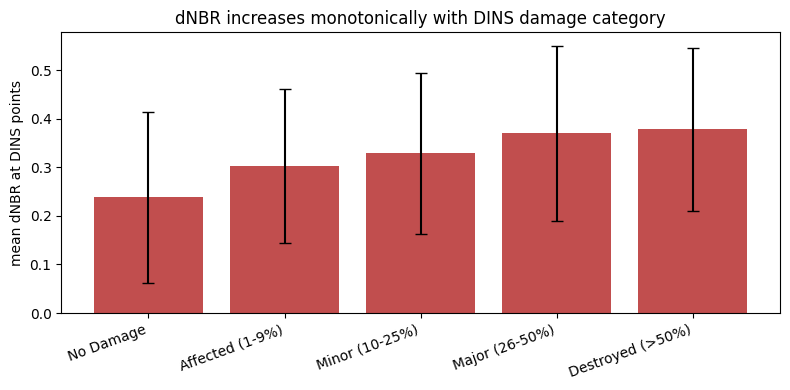

In [19]:
dins_path = DATA_DIR.parent.parent / "reference" / "dins" / "palisades_dins.geojson"
try:
    dins = tanager.load_dins_reference(dins_path)  # -> UTM 11N + damage_ordinal column
except FileNotFoundError as exc:
    dins = None
    print(
        f"DINS survey not bundled locally ({exc}); skipping structure-level cross-check. "
        "The Palisades DINS GeoJSON is available from the CAL FIRE DINS viewer / data.ca.gov."
    )

if dins is not None:
    dins_check = tanager.cross_check_dins(dins, dnbr_da, product_name="dNBR")

    print(
        f"{dins_check['n_valid']} of {dins_check['n_points']} DINS structures fall on "
        f"valid dNBR pixels ({dins_check['n_outside']} outside the swath-2 overlap)\n"
    )
    print(f"{'category':<20} {'n':>5} {'mean':>7} {'median':>7} {'std':>6}")
    for cat, s in dins_check["per_category"].items():
        print(f"{cat:<20} {s['count']:>5} {s['mean']:>7.3f} {s['median']:>7.3f} {s['std']:>6.3f}")

    b = dins_check["binary"]
    print(
        f"\nBinary 'any damage' detection @ dNBR >= {b['threshold']:.2f}: "
        f"recall={b['recall']:.3f} precision={b['precision']:.3f} "
        f"F1={b['f1']:.3f} accuracy={b['accuracy']:.3f}"
    )
    print(f"Spearman rho (damage ordinal vs dNBR): {dins_check['spearman_rho']:.3f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    cats = list(dins_check["per_category"])
    means = [dins_check["per_category"][c]["mean"] for c in cats]
    stds = [dins_check["per_category"][c]["std"] for c in cats]
    ax.bar(range(len(cats)), means, yerr=stds, capsize=4, color="firebrick", alpha=0.8)
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=20, ha="right")
    ax.set_ylabel("mean dNBR at DINS points")
    ax.set_title("dNBR increases monotonically with DINS damage category")
    plt.tight_layout()
    plt.show()

## 8. Discussion

**What this notebook demonstrates.** The FireSpec burn-severity pipeline runs end-to-end
on real Tanager-1 imagery: quality masking → spatial alignment → image-derived endmember
extraction → MESMA spectral unmixing → severity classification → visualization →
validation against independent BAER ground truth. The fraction maps in Section 4 show
physically sensible spatial structure, and Section 6's internal-consistency check finds
char fraction rising monotonically across the burned classes — the unmixing and the
burn-ratio, which share no arithmetic, agree on how hard each pixel inside the scar
burned.

**Real ground-truth evaluation.** The severity model is trained and evaluated against
**BAER Soil Burn Severity** — a field-corrected, independently produced severity product
— on the Hughes fire (same sensor, same overpass). Two approaches are compared:

1. **RF classifier (MESMA fractions → BAER SBS):** A Random Forest trained on the 4-fraction
   feature vector (char/PV/NPV/soil) from MESMA unmixing, targeting BAER severity classes.
   This is the primary severity product and the one that exercises Tanager-1's hyperspectral
   advantage — it uses the full sub-pixel material decomposition, not just a band ratio.
   Cross-validated metrics are reported in Section 7.

2. **NBR-threshold baseline:** Single-date post-fire NBR with thresholds calibrated from
   BAER class medians. This is the simpler, spectral-ratio approach that any broadband
   sensor could replicate.

**What replaced the synthetic CBI proxy.** An earlier revision of this notebook trained
a Random Forest *regressor* against a synthetic target (`CBI = 3 × char_fraction`) and
reported R² = 0.998 / RMSE = 0.037. That result was circular — measuring only the
regressor's ability to invert a deterministic function of its own input — and has been
replaced. The RF *classifier* in Section 7 trains against real, independently measured
BAER SBS classes: its accuracy reflects genuine predictive skill, not circular agreement.
The synthetic CBI path (`tanager.train_severity_model()`) remains in the codebase as a
documented fallback for fires where no BAER/MTBS reference exists.

**What is a stand-in, not a finished scientific product, and why:**

- **Validation is on a different fire than the product.** The BAER raster covers Hughes,
  not Palisades; the two differ in fuel and terrain, and Hughes lacks a pre-fire scene so
  its NBR-threshold validation uses single-date NBR rather than dNBR. Section 7 spells out
  both gaps. The RF classifier is trained on Hughes and applied to Palisades — a genuine
  cross-fire transfer, not same-fire accuracy.
- **The BAER raster's class coding was inferred, not documented.** `hughes_sbs.tif` ships
  with no colormap or metadata tags. Its coding (0 = outside mapped extent, 15 = unburned
  inside perimeter, 1–4 = Low…High) was established by inspecting the raster's spatial
  structure and per-class NBR/NDVI, and is recorded in Section 7's cell.
- **Fraction non-negativity.** MESMA's constrained solver still lets 5–9% of pixels
  violate non-negativity before `normalize_fractions()` clamps and re-normalizes (Section
  4). This is a known limitation of FCLS-style constraint enforcement, not a bug; the
  clamp is a standard, documented mitigation (Roberts et al. 2018).
- **Single-scene, image-derived endmembers.** With no external spectral library bundled
  locally, char/PV/NPV/soil endmembers are extracted from the post-fire scene itself via
  percentile-based region selection (Section 3). A proper submission-grade library —
  resampled external spectra pruned via EAR/MASA — would better separate spectrally
  similar classes (e.g. dry soil vs. light char).
- **Crop, not full scene.** Sections 3–5 run on a ~300×300 px crop centered on the
  strongest dNBR signal. Full-scene MESMA products from the same pipeline exist in
  `outputs/` from `scripts/run_pipeline.py`.
- **Spatial coverage gap.** The pre/post overlap covers the western Palisades/Topanga
  front but not the easternmost Pacific Palisades or the Eaton fire footprint.

**What's next.** Notebook 03 estimates live fuel moisture content from the same
hyperspectral cubes; Notebook 04 extends this severity analysis into a multi-date recovery
trajectory (stratified by the BARC classes computed here); Notebook 05 quantifies how much
of this analysis degrades if run at EMIT/PRISMA/Sentinel-2 spectral resolution instead of
Tanager's native 426 bands.